In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [3]:
iris = load_iris()

X = iris.data
y = iris.target
print("Feature names:")
print(iris.feature_names)

print("\nTarget names:")
print(iris.target_names)

print("\nShape of dataset:", X.shape)

Feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target names:
['setosa' 'versicolor' 'virginica']

Shape of dataset: (150, 4)


In [4]:
y_binary = (y != 0).astype(int)

print("Binary labels:")
print(np.unique(y_binary, return_counts=True))

Binary labels:
(array([0, 1]), array([ 50, 100]))


In [8]:
#split two features for visualization
X_two = X[:, [2,3]]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_two, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

In [10]:
#standardize the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
#train the linear SVM
linear_svm = SVC(
    kernel= 'linear', C= 1.0
)
linear_svm.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [16]:
#make predictions
y_pred = linear_svm.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        20

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



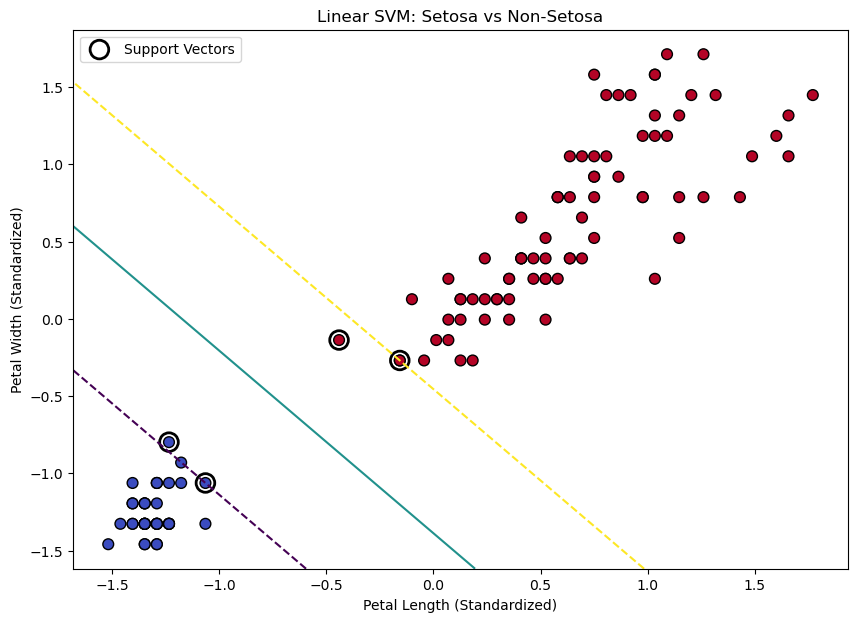

In [19]:
#visualize decision boundary.margins and support vectors
plt.figure(figsize=(10,7))

#plot training points
plt.scatter(
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    c=y_train,
    s=60,
    cmap= 'coolwarm',
    edgecolors='k'
)
#create grid
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 200)
yy = np.linspace(ylim[0], ylim[1], 200)

YY, XX = np.meshgrid(yy, xx)

xy = np.vstack([XX.ravel(), YY.ravel()]).T

#calculate decision function
Z = linear_svm.decision_function(xy)

Z = Z.reshape(XX.shape)

#draw decision bountary and margins
ax.contour(
    XX, YY, Z, levels=[-1,0,1],
    linestyles=['--', '-', '--']
)

#highlight support vectors
ax.scatter(
    linear_svm.support_vectors_[:, 0],
    linear_svm.support_vectors_[:, 1],
    s=180,
    facecolors='none',
    edgecolors='black',
    linewidths=2,
    label='Support Vectors'
)
plt.xlabel("Petal Length (Standardized)")
plt.ylabel("Petal Width (Standardized)")
plt.title("Linear SVM: Setosa vs Non-Setosa")

plt.legend()
plt.show()

In [22]:
# use all four features and the original three-class target
X_full = iris.data
y_full = iris.target

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full,
    y_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full
)
scaler_full = StandardScaler()

X_train_full = scaler_full.fit_transform(X_train_full)
X_test_full = scaler_full.transform(X_test_full)

In [25]:
#Create linear, polynomial and RBF SVM models
models = {
    "Linear": SVC(kernel="linear", C=1.0),
    "Polynomial": SVC(kernel="poly", degree=3, C=1.0),
    "RBF": SVC(kernel="rbf", C=1.0, gamma="scale")
}

In [30]:
#train and compare
results = {}
for name, model in models.items():
     model.fit(X_train_full, y_train_full)
     y_pred = model.predict(X_test_full)
     accuracy = accuracy_score(y_test_full, y_pred)
     results[name] = accuracy

     print("-"*52)
     print(f"\n{name} Kernel")
     print("-"*52)
     print("Accuracy:", accuracy)

     print(
         classification_report(
               y_test_full, y_pred, target_names=iris.target_names
         )
     )
     

----------------------------------------------------

Linear Kernel
----------------------------------------------------
Accuracy: 1.0
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

----------------------------------------------------

Polynomial Kernel
----------------------------------------------------
Accuracy: 0.9
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.77      1.00      0.87        10
   virginica       1.00      0.70      0.82        10

    accuracy                           0.90        30
   macro avg       0.92      0.90      0.90        30
weighted avg       